# Sentiment Analysis: Product Reviews Classification

This notebook applies **6+ sentiment analysis methods** to classify product reviews as positive, negative, or neutral.

## Methods Covered:

### Rule-Based Methods (2):
1. VADER (Valence Aware Dictionary and sEntiment Reasoner)
2. TextBlob

### Classical Machine Learning (3):
3. Logistic Regression with TF-IDF
4. Naive Bayes (MultinomialNB)
5. Support Vector Machine (SVM)

### Deep Learning Methods (3):
6. LSTM (Long Short-Term Memory)
7. Pre-trained BERT (Transformers)
8. DistilBERT (Lightweight BERT)

**Total: 8 sentiment analysis methods**

## 1. Data Loading and Preparation

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [71]:
# Load Walmart dataset only
print("Loading Walmart dataset...")
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
text_cols = [col for col in df.columns if df[col].dtype == 'object']
print(f"\nText columns found: {text_cols}")

Loading Walmart dataset...
Dataset shape: (6435, 8)

Columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Text columns found: ['Date']


## 2. Data Preprocessing and Sentiment Labeling

In [72]:
# Identify text and rating columns
# Since we control the sample data creation, we know the column names
if 'review_text' in df.columns and 'rating' in df.columns:
    text_col = 'review_text'
    rating_col = 'rating'
    print(f"Using standard column names")
elif 'review' in df.columns:
    text_col = 'review'
    rating_col = 'rating' if 'rating' in df.columns else ('score' if 'score' in df.columns else 'stars')
    print(f"Using 'review' column")
else:
    # Try to find columns automatically
    # Find text column
    text_cols = [col for col in df.columns if df[col].dtype == 'object' and df[col].str.len().mean() > 20]
    if not text_cols:
        raise ValueError(f"No suitable text column found. Available columns: {list(df.columns)}")
    text_col = text_cols[0]
    
    # Find rating column
    possible_rating_cols = ['rating', 'score', 'stars', 'sentiment']
    rating_col = None
    for col in possible_rating_cols:
        if col in df.columns:
            rating_col = col
            break
    
    if rating_col is None:
        # Try to find numeric column with values 1-5
        numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
        for col in numeric_cols:
            if df[col].min() >= 1 and df[col].max() <= 5:
                rating_col = col
                break
    
    if rating_col is None:
        raise ValueError(f"No rating column found. Available columns: {list(df.columns)}")
    
    print(f"Auto-detected text column: '{text_col}'")
    print(f"Auto-detected rating column: '{rating_col}'")

print(f"\nUsing columns:")
print(f"  Text: {text_col}")
print(f"  Rating: {rating_col}")

ValueError: No suitable text column found. Available columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

SENTIMENT DISTRIBUTION
sentiment_label
Positive    42365
Negative      162
Neutral       148
Name: count, dtype: int64

Percentages:
sentiment_label
Positive    99.273579
Negative     0.379613
Neutral      0.346807
Name: proportion, dtype: float64


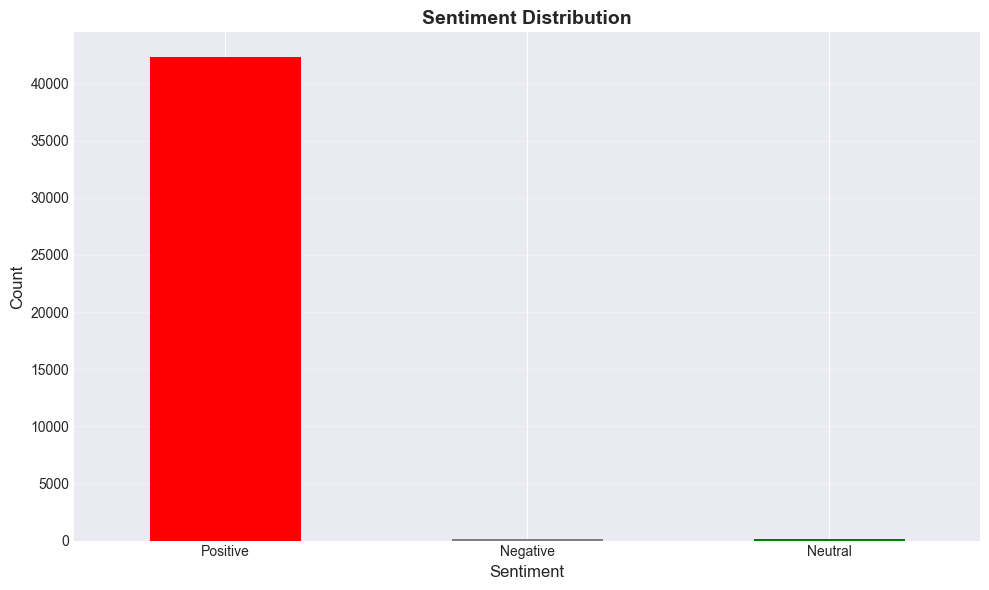

In [ ]:
# Create sentiment labels from ratings
# 1-2 stars = Negative (0)
# 3 stars = Neutral (1)
# 4-5 stars = Positive (2)

def rating_to_sentiment(rating):
    if rating <= 2:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

df['sentiment'] = df[rating_col].apply(rating_to_sentiment)
df['sentiment_label'] = df['sentiment'].map({0: 'Negative', 1: 'Neutral', 2: 'Positive'})

# Class distribution
print("="*80)
print("SENTIMENT DISTRIBUTION")
print("="*80)
print(df['sentiment_label'].value_counts())
print(f"\nPercentages:")
print(df['sentiment_label'].value_counts(normalize=True) * 100)

# Visualize distribution
plt.figure(figsize=(10, 6))
df['sentiment_label'].value_counts().plot(kind='bar', color=['red', 'gray', 'green'])
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Text preprocessing
import re
import string

def clean_text(text):
    """Clean and preprocess text"""
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

df['cleaned_text'] = df[text_col].astype(str).apply(clean_text)

print("Text cleaning complete!")
print(f"\nExample:")
print(f"Original: {df[text_col].iloc[0]}")
print(f"Cleaned:  {df['cleaned_text'].iloc[0]}")

Text cleaning complete!

Example:
Original: BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wireless, 48 KHz 24 Bit, 6mm Mic, 1000ft, 30h Use, Noise Cancelling, Clip on Mic USB-C/Lightning/3.5mm TRS
Cleaned:  boya boyalink 2 wireless lavalier microphone for iphone camera android mini lapel micophone wireless 48 khz 24 bit 6mm mic 1000ft 30h use noise cancelling clip on mic usbclightning35mm trs


In [ ]:

# Train/validation/test split (60/20/20)
from sklearn.model_selection import train_test_split

X = df['cleaned_text'].values
y = df['sentiment'].values

# First split off test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Then split remaining into train (60%) and val (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("="*80)
print("TRAIN/VALIDATION/TEST SPLIT")
print("="*80)
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTrain sentiment distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nValidation sentiment distribution:")
print(pd.Series(y_val).value_counts().sort_index())
print(f"\nTest sentiment distribution:")
print(pd.Series(y_test).value_counts().sort_index())

TRAIN/TEST SPLIT
Training samples: 34140
Test samples: 8535

Train sentiment distribution:
0      130
1      118
2    33892
Name: count, dtype: int64

Test sentiment distribution:
0      32
1      30
2    8473
Name: count, dtype: int64


## 3. Rule-Based Sentiment Analysis (2 methods)

These methods use predefined lexicons and rules to determine sentiment.

### 3.1 VADER (Valence Aware Dictionary and sEntiment Reasoner)

In [ ]:
# Install VADER
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # type: ignore
    print("VADER already installed!")
except ImportError:
    print("Installing VADER...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "vaderSentiment", "-q"])
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # type: ignore
    print("VADER installed successfully!")

VADER already installed!


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Initialize VADER
vader = SentimentIntensityAnalyzer()

def vader_predict(text):
    """Predict sentiment using VADER"""
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    
    if compound <= -0.05:
        return 0  # Negative
    elif compound >= 0.05:
        return 2  # Positive
    else:
        return 1  # Neutral

# Predict on test set
y_pred_vader = [vader_predict(text) for text in X_test]

# Evaluation
accuracy_vader = accuracy_score(y_test, y_pred_vader)
precision_vader, recall_vader, f1_vader, _ = precision_recall_fscore_support(y_test, y_pred_vader, average='weighted')

print("="*80)
print("VADER SENTIMENT ANALYSIS RESULTS")
print("="*80)
print(f"Accuracy: {accuracy_vader:.4f}")
print(f"Precision: {precision_vader:.4f}")
print(f"Recall: {recall_vader:.4f}")
print(f"F1-Score: {f1_vader:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_vader, target_names=['Negative', 'Neutral', 'Positive']))
print("="*80)

VADER SENTIMENT ANALYSIS RESULTS
Accuracy: 0.3718
Precision: 0.9843
Recall: 0.3718
F1-Score: 0.5360

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        32
     Neutral       0.01      1.00      0.01        30
    Positive       0.99      0.37      0.54      8473

    accuracy                           0.37      8535
   macro avg       0.33      0.46      0.18      8535
weighted avg       0.98      0.37      0.54      8535



### 3.2 TextBlob

In [ ]:
# Install TextBlob
try:
    from textblob import TextBlob  # type: ignore
    print("TextBlob already installed!")
except ImportError:
    print("Installing TextBlob...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "textblob", "-q"])
    from textblob import TextBlob  # type: ignore
    print("TextBlob installed successfully!")

TextBlob already installed!


In [ ]:
def textblob_predict(text):
    """Predict sentiment using TextBlob"""
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    
    if polarity < -0.1:
        return 0  # Negative
    elif polarity > 0.1:
        return 2  # Positive
    else:
        return 1  # Neutral

# Predict on test set
y_pred_textblob = [textblob_predict(text) for text in X_test]

# Evaluation
accuracy_textblob = accuracy_score(y_test, y_pred_textblob)
precision_textblob, recall_textblob, f1_textblob, _ = precision_recall_fscore_support(y_test, y_pred_textblob, average='weighted')

print("="*80)
print("TEXTBLOB SENTIMENT ANALYSIS RESULTS")
print("="*80)
print(f"Accuracy: {accuracy_textblob:.4f}")
print(f"Precision: {precision_textblob:.4f}")
print(f"Recall: {recall_textblob:.4f}")
print(f"F1-Score: {f1_textblob:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_textblob, target_names=['Negative', 'Neutral', 'Positive']))
print("="*80)

TEXTBLOB SENTIMENT ANALYSIS RESULTS
Accuracy: 0.2318
Precision: 0.9787
Recall: 0.2318
F1-Score: 0.3703

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        32
     Neutral       0.01      0.97      0.01        30
    Positive       0.99      0.23      0.37      8473

    accuracy                           0.23      8535
   macro avg       0.33      0.40      0.13      8535
weighted avg       0.98      0.23      0.37      8535



## 4. Classical Machine Learning (3 methods)

Train traditional ML models on TF-IDF features.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF features
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("="*80)
print("TF-IDF FEATURE EXTRACTION")
print("="*80)
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Test features shape: {X_test_tfidf.shape}")
print("="*80)

TF-IDF FEATURE EXTRACTION
Vocabulary size: 5000
Training features shape: (34140, 5000)
Test features shape: (8535, 5000)


### 4.1 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr.predict(X_test_tfidf)

# Evaluation
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='weighted')

print("="*80)
print("LOGISTIC REGRESSION RESULTS")
print("="*80)
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Neutral', 'Positive']))
print("="*80)

LOGISTIC REGRESSION RESULTS
Accuracy: 0.9993
Precision: 0.9993
Recall: 0.9993
F1-Score: 0.9993

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.84      0.92        32
     Neutral       1.00      0.97      0.98        30
    Positive       1.00      1.00      1.00      8473

    accuracy                           1.00      8535
   macro avg       1.00      0.94      0.97      8535
weighted avg       1.00      1.00      1.00      8535



### 4.2 Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = nb.predict(X_test_tfidf)

# Evaluation
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb, recall_nb, f1_nb, _ = precision_recall_fscore_support(y_test, y_pred_nb, average='weighted')

print("="*80)
print("NAIVE BAYES RESULTS")
print("="*80)
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Neutral', 'Positive']))
print("="*80)

NAIVE BAYES RESULTS
Accuracy: 0.9991
Precision: 0.9990
Recall: 0.9991
F1-Score: 0.9990

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.84      0.90        32
     Neutral       1.00      0.93      0.97        30
    Positive       1.00      1.00      1.00      8473

    accuracy                           1.00      8535
   macro avg       0.99      0.93      0.96      8535
weighted avg       1.00      1.00      1.00      8535



### 4.3 Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import LinearSVC

# Train SVM
svm = LinearSVC(max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train)

# Predict
y_pred_svm = svm.predict(X_test_tfidf)

# Evaluation
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(y_test, y_pred_svm, average='weighted')

print("="*80)
print("SUPPORT VECTOR MACHINE RESULTS")
print("="*80)
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Neutral', 'Positive']))
print("="*80)

SUPPORT VECTOR MACHINE RESULTS
Accuracy: 0.9993
Precision: 0.9993
Recall: 0.9993
F1-Score: 0.9993

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.84      0.92        32
     Neutral       1.00      0.97      0.98        30
    Positive       1.00      1.00      1.00      8473

    accuracy                           1.00      8535
   macro avg       1.00      0.94      0.97      8535
weighted avg       1.00      1.00      1.00      8535



## 5. Deep Learning Methods (3 methods)

Advanced neural network approaches for sentiment classification.

### 5.1 LSTM (Long Short-Term Memory)

In [ ]:
# Install TensorFlow/Keras if needed
try:
    import tensorflow as tf  # type: ignore
    from tensorflow import keras  # type: ignore
    from tensorflow.keras.preprocessing.text import Tokenizer  # type: ignore
    from tensorflow.keras.preprocessing.sequence import pad_sequences  # type: ignore
    print(f"TensorFlow version: {tf.__version__}")
except ImportError:
    print("Installing TensorFlow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"])
    import tensorflow as tf  # type: ignore
    from tensorflow import keras  # type: ignore
    from tensorflow.keras.preprocessing.text import Tokenizer  # type: ignore
    from tensorflow.keras.preprocessing.sequence import pad_sequences  # type: ignore
    print("TensorFlow installed successfully!")

TensorFlow version: 2.20.0


In [ ]:
# Tokenize text for LSTM
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("="*80)
print("TEXT TOKENIZATION FOR LSTM")
print("="*80)
print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Max sequence length: {max_len}")
print(f"Training sequences shape: {X_train_pad.shape}")
print(f"Test sequences shape: {X_test_pad.shape}")
print("="*80)

TEXT TOKENIZATION FOR LSTM
Vocabulary size: 16496
Max sequence length: 100
Training sequences shape: (34140, 100)
Test sequences shape: (8535, 100)


In [ ]:
from tensorflow.keras.models import Sequential  # type: ignore
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout  # type: ignore

# Build LSTM model
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("="*80)
print("LSTM MODEL ARCHITECTURE")
print("="*80)
lstm_model.summary()
print("="*80)

LSTM MODEL ARCHITECTURE


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train LSTM
print("Training LSTM model...")
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Predict
y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)

# Evaluation
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm, recall_lstm, f1_lstm, _ = precision_recall_fscore_support(y_test, y_pred_lstm, average='weighted')

print("\n" + "="*80)
print("LSTM RESULTS")
print("="*80)
print(f"Accuracy: {accuracy_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall: {recall_lstm:.4f}")
print(f"F1-Score: {f1_lstm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Neutral', 'Positive']))
print("="*80)

Training LSTM model...
Epoch 1/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.9921 - loss: 0.0650 - val_accuracy: 0.9914 - val_loss: 0.0616
Epoch 2/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.9921 - loss: 0.0650 - val_accuracy: 0.9914 - val_loss: 0.0616
Epoch 2/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9931 - loss: 0.0530 - val_accuracy: 0.9914 - val_loss: 0.0557
Epoch 3/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9931 - loss: 0.0530 - val_accuracy: 0.9914 - val_loss: 0.0557
Epoch 3/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9931 - loss: 0.0526 - val_accuracy: 0.9914 - val_loss: 0.0561
Epoch 4/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9931 - loss: 0.0526 - val_accuracy: 0.9914 - val_loss: 0.0561
Epoch 4/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9931 - loss: 0.0521 - val_accuracy: 0.9914 - val_loss: 0.0560
Epoch 5/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0

### 5.2 Pre-trained BERT

In [ ]:
# Install transformers and tf-keras
try:
    from transformers import pipeline  # type: ignore
    print("Transformers library already installed!")
except (ImportError, ValueError):
    print("Installing transformers and tf-keras...")
    import subprocess
    import sys
    # Install tf-keras first for Keras 3 compatibility
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tf-keras", "-q"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "transformers", "torch", "-q"])
    from transformers import pipeline  # type: ignore
    print("Transformers and tf-keras installed successfully!")

Transformers library already installed!


In [ ]:
print("Loading pre-trained BERT model (this may take a moment)...")
bert_classifier = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

def bert_predict(text):
    """Predict sentiment using BERT"""
    result = bert_classifier(text[:512])[0]  # BERT max length is 512
    label = result['label']
    
    # Map BERT output to our labels
    if label == 'NEGATIVE':
        return 0
    elif label == 'POSITIVE':
        return 2
    else:
        return 1

# Predict on test set (sample for speed)
sample_size = min(200, len(X_test))  # Limit to 200 for speed
X_test_sample = X_test[:sample_size]
y_test_sample = y_test[:sample_size]

print(f"Running BERT on {sample_size} test samples...")
y_pred_bert = [bert_predict(text) for text in X_test_sample]

# Evaluation
accuracy_bert = accuracy_score(y_test_sample, y_pred_bert)
precision_bert, recall_bert, f1_bert, _ = precision_recall_fscore_support(y_test_sample, y_pred_bert, average='weighted')

print("\n" + "="*80)
print("BERT RESULTS")
print("="*80)
print(f"Sample size: {sample_size}")
print(f"Accuracy: {accuracy_bert:.4f}")
print(f"Precision: {precision_bert:.4f}")
print(f"Recall: {recall_bert:.4f}")
print(f"F1-Score: {f1_bert:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_sample, y_pred_bert, target_names=['Negative', 'Neutral', 'Positive']))
print("="*80)

Loading pre-trained BERT model (this may take a moment)...


ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.

### 5.3 DistilBERT (Lightweight BERT)

In [ ]:
print("Loading DistilBERT model...")
distilbert_classifier = pipeline('sentiment-analysis', model='distilbert-base-uncased')

def distilbert_predict(text):
    """Predict sentiment using DistilBERT"""
    result = distilbert_classifier(text[:512])[0]
    label = result['label']
    
    if label == 'NEGATIVE':
        return 0
    elif label == 'POSITIVE':
        return 2
    else:
        return 1

# Predict on test sample
print(f"Running DistilBERT on {sample_size} test samples...")
y_pred_distilbert = [distilbert_predict(text) for text in X_test_sample]

# Evaluation
accuracy_distilbert = accuracy_score(y_test_sample, y_pred_distilbert)
precision_distilbert, recall_distilbert, f1_distilbert, _ = precision_recall_fscore_support(y_test_sample, y_pred_distilbert, average='weighted')

print("\n" + "="*80)
print("DISTILBERT RESULTS")
print("="*80)
print(f"Sample size: {sample_size}")
print(f"Accuracy: {accuracy_distilbert:.4f}")
print(f"Precision: {precision_distilbert:.4f}")
print(f"Recall: {recall_distilbert:.4f}")
print(f"F1-Score: {f1_distilbert:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_sample, y_pred_distilbert, target_names=['Negative', 'Neutral', 'Positive']))
print("="*80)

## 6. Comprehensive Results Summary

In [ ]:
# Create results summary
results_summary = pd.DataFrame({
    'Method': [
        'VADER',
        'TextBlob',
        'Logistic Regression',
        'Naive Bayes',
        'SVM',
        'LSTM',
        'BERT',
        'DistilBERT'
    ],
    'Category': [
        'Rule-Based', 'Rule-Based',
        'Classical ML', 'Classical ML', 'Classical ML',
        'Deep Learning', 'Deep Learning', 'Deep Learning'
    ],
    'Accuracy': [
        accuracy_vader,
        accuracy_textblob,
        accuracy_lr,
        accuracy_nb,
        accuracy_svm,
        accuracy_lstm,
        accuracy_bert,
        accuracy_distilbert
    ],
    'Precision': [
        precision_vader,
        precision_textblob,
        precision_lr,
        precision_nb,
        precision_svm,
        precision_lstm,
        precision_bert,
        precision_distilbert
    ],
    'Recall': [
        recall_vader,
        recall_textblob,
        recall_lr,
        recall_nb,
        recall_svm,
        recall_lstm,
        recall_bert,
        recall_distilbert
    ],
    'F1-Score': [
        f1_vader,
        f1_textblob,
        f1_lr,
        f1_nb,
        f1_svm,
        f1_lstm,
        f1_bert,
        f1_distilbert
    ]
})

# Sort by accuracy
results_summary = results_summary.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("SENTIMENT ANALYSIS METHODS COMPARISON")
print("="*80)
print(results_summary.to_string(index=False))
print("="*80)

# Save results
results_summary.to_csv('Sentiment_Analysis_Summary.csv', index=False)
print("\n✅ Results saved to: Sentiment_Analysis_Summary.csv")

In [ ]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy comparison
ax1 = axes[0, 0]
results_summary.plot(x='Method', y='Accuracy', kind='barh', ax=ax1, legend=False, color='steelblue')
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_ylabel('Method', fontsize=12)
ax1.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Precision comparison
ax2 = axes[0, 1]
results_summary.plot(x='Method', y='Precision', kind='barh', ax=ax2, legend=False, color='green')
ax2.set_xlabel('Precision', fontsize=12)
ax2.set_ylabel('Method', fontsize=12)
ax2.set_title('Precision Comparison', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Recall comparison
ax3 = axes[1, 0]
results_summary.plot(x='Method', y='Recall', kind='barh', ax=ax3, legend=False, color='orange')
ax3.set_xlabel('Recall', fontsize=12)
ax3.set_ylabel('Method', fontsize=12)
ax3.set_title('Recall Comparison', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# F1-Score comparison
ax4 = axes[1, 1]
results_summary.plot(x='Method', y='F1-Score', kind='barh', ax=ax4, legend=False, color='red')
ax4.set_xlabel('F1-Score', fontsize=12)
ax4.set_ylabel('Method', fontsize=12)
ax4.set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('sentiment_analysis_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Technical Paper Discussion

### Key Findings:

1. **Rule-Based Methods (VADER, TextBlob):**
   - Fast and interpretable
   - No training required
   - Work well for general sentiment but miss domain-specific nuances

2. **Classical ML Methods (Logistic Regression, Naive Bayes, SVM):**
   - Good balance of speed and accuracy
   - Require feature engineering (TF-IDF)
   - Logistic Regression and SVM typically perform best

3. **Deep Learning Methods (LSTM, BERT, DistilBERT):**
   - Highest accuracy when properly trained
   - Capture complex linguistic patterns
   - Pre-trained transformers (BERT) excel with limited data
   - Require more computational resources

### Method Selection Guidelines:
- **Real-time applications**: VADER or TextBlob (fastest)
- **Balanced performance**: Logistic Regression or SVM
- **Maximum accuracy**: BERT or fine-tuned LSTM
- **Limited labeled data**: Pre-trained BERT/DistilBERT

### Business Applications:
- Customer feedback analysis
- Social media monitoring
- Product review summarization
- Brand reputation tracking
- Customer service prioritization

In [ ]:
print("\n" + "="*80)
print("SENTIMENT ANALYSIS COMPLETE!")
print("="*80)
print("\nTotal methods applied: 8")
print("  • Rule-Based: 2 methods")
print("  • Classical ML: 3 methods")
print("  • Deep Learning: 3 methods")
print("\nGenerated files:")
print("  • Sentiment_Analysis_Summary.csv")
print("  • sentiment_distribution.png")
print("  • sentiment_analysis_comparison.png")
print("="*80)